                    time  freq   flag           err   ppb
3269 2025-12-06 12:38:00   1.0  False  3.300000e-08  33.0
3270 2025-12-06 12:38:01   1.0  False  2.900000e-08  29.0
3271 2025-12-06 12:38:02   1.0  False -5.000000e-09  -5.0
3272 2025-12-06 12:38:03   1.0  False  1.000000e-08  10.0
3273 2025-12-06 12:38:04   1.0  False -1.900000e-08 -19.0
Max error: 0.002251518000000008
Time of max error: 2025-12-06 12:15:25.996889344


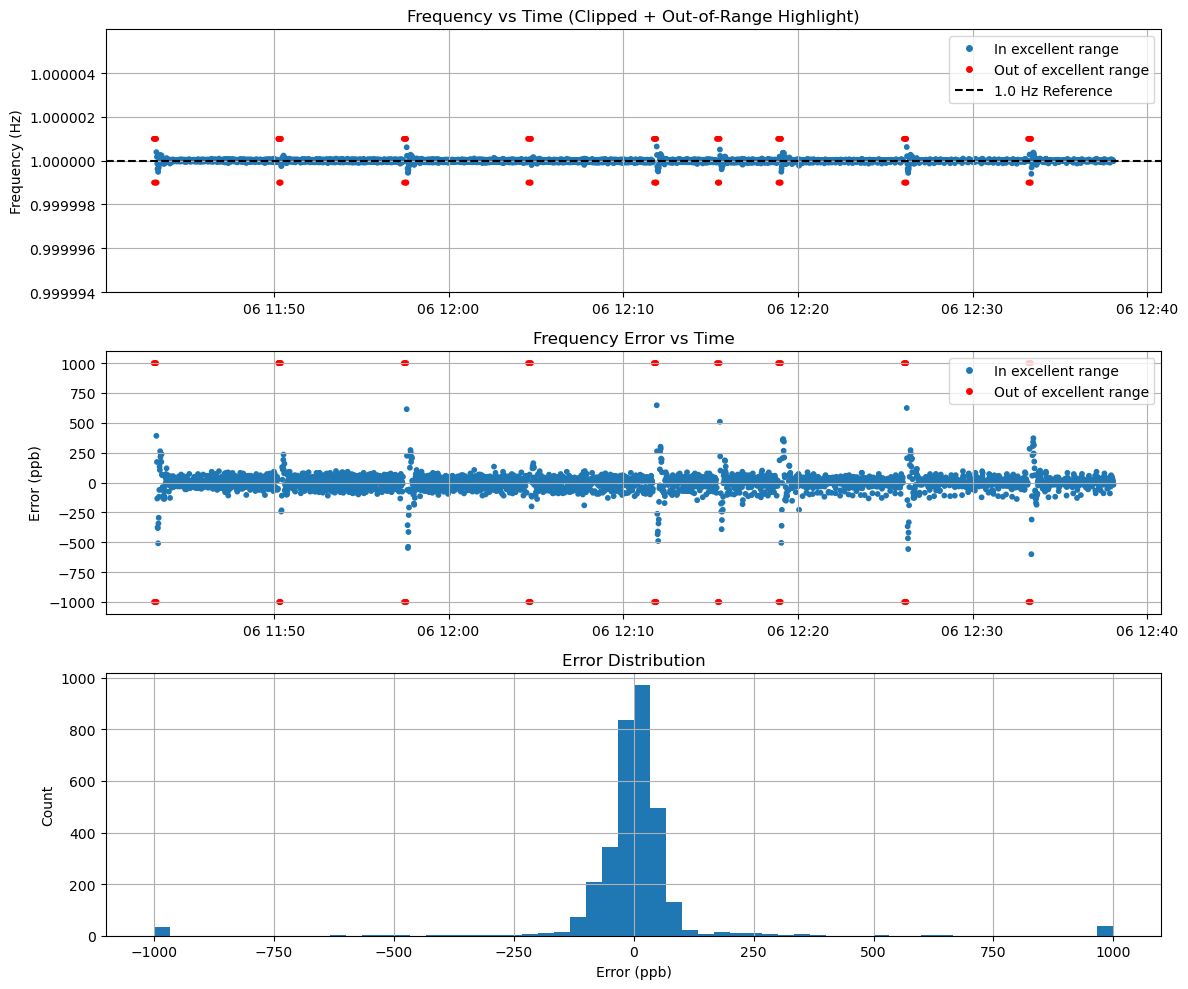

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example: parse a log text file with lines like:
# "CH2 1687105246.999762138" and "Frequency: 0.999882" or lines containing "Skip cycle"
# Adjust parsing to your format.

def parse_log(path):
    times, freqs, flags = [], [], []
    with open(path) as f:
        for line in f:
            if "CH0" in line:
                # get timestamp token and next "Frequency:" line will hold freq
                parts = line.split()
                # example: CH2 <ts>
                ts = float(parts[2])
                # next line contains Frequency
                next_line = next(f).strip()
                if "Frequency" in next_line:
                    freq = float(next_line.split(':')[1])
                    times.append(pd.to_datetime(ts, unit='s'))
                    freqs.append(freq)
                    flags.append(False)
            elif "Skip cycle" in line or "lose second sync" in line:
                # store marker row
                times.append(pd.NaT)
                freqs.append(np.nan)
                flags.append(True)
    df = pd.DataFrame({'time': times, 'freq': freqs, 'flag': flags})
    df = df.dropna(subset=['time']).reset_index(drop=True)
    return df

# Example usage
df = parse_log('data/thesis_1hz.txt')
# For demo I'll create sample data
#import math, random, datetime
#t0 = pd.Timestamp.now()
#df = pd.DataFrame({'time':[t0 + pd.Timedelta(seconds=i) for i in range(600)],
#                  'freq':[1.0 + random.gauss(0,5e-4) + 1e-6*math.sin(i/30) for i in range(600)]})

df['err'] = df['freq'] - 1.0
df['ppb'] = df['err'] * 1e9
print (df.tail(5))
max_err = df['err'].max()
time_of_max_err = df.loc[df['err'].idxmax(), 'time']

print("Max error:", max_err)
print("Time of max error:", time_of_max_err)

import matplotlib.pyplot as plt

# Create ONE figure with 3 subplots (stacked vertically)
plt.figure(figsize=(12, 10))

# ─────────────────────────────
# 1) Frequency vs Time
# ─────────────────────────────
# Normal range
NORMAL_MIN_HZ = 0.999999000
NORMAL_MAX_HZ = 1.000000999

# Normal PPB range
NORMAL_MIN_PPB = -1000.0
NORMAL_MAX_PPB = 1000.0

# ─────────────────────────────
# 1) Frequency vs Time (Scatter with clipping)
# ─────────────────────────────
ax1 = plt.subplot(3, 1, 1)

# Clip values for plotting
freq_clipped = df['freq'].clip(NORMAL_MIN_HZ, NORMAL_MAX_HZ)

# Color map: in-range = blue, out-of-range = red
colors = df['freq'].apply(
    lambda x: 'C0' if NORMAL_MIN_HZ <= x <= NORMAL_MAX_HZ else 'red'
)

# Scatter plot
ax1.scatter(df['time'], freq_clipped, s=10, c=colors)

# 1.0 Hz reference
ax1.axhline(1.0, color='k', linestyle='--')

# Focus y-axis around the normal range
buffer = 5e-6
ax1.set_ylim(NORMAL_MIN_HZ - buffer, NORMAL_MAX_HZ + buffer)

# --- FORMAL FIX FOR BAD Y-AXIS ---
ax1.ticklabel_format(style='plain', axis='y')
ax1.get_yaxis().get_major_formatter().set_useOffset(False)
ax1.get_yaxis().get_major_formatter().set_scientific(False)
# ---------------------------------

ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Frequency vs Time (Clipped + Out-of-Range Highlight)')
ax1.grid(True)

# ---- Custom legend for in-range, out-of-range, and reference ----
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',
           markersize=6, label='In excellent range'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=6, label='Out of excellent range'),
    Line2D([0], [0], color='k', linestyle='--', label='1.0 Hz Reference')
]

ax1.legend(handles=legend_elements, loc='upper right')


# ─────────────────────────────
# 2) Error vs Time (ppb)
# ─────────────────────────────
ax2=plt.subplot(3, 1, 2)
ppb_clipped = df['ppb'].clip(NORMAL_MIN_PPB, NORMAL_MAX_PPB)
# Color map: in-range = blue, out-of-range = red
colors = df['ppb'].apply(
    lambda x: 'C0' if NORMAL_MIN_PPB <= x <= NORMAL_MAX_PPB else 'red'
)
plt.scatter(df['time'], ppb_clipped, s=10, c=colors, label='Error (ppb)')
plt.ylabel('Error (ppb)')
ax2.legend(handles=legend_elements[:2],loc='upper right')
plt.title('Frequency Error vs Time')
plt.grid(True)

# ─────────────────────────────
# 3) Histogram of Error
# ─────────────────────────────
ppb_clipped_for_hist = df['ppb'].clip(NORMAL_MIN_PPB, NORMAL_MAX_PPB)
plt.subplot(3, 1, 3)
plt.hist(ppb_clipped_for_hist, bins=60)
plt.xlabel('Error (ppb)')
plt.ylabel('Count')
plt.title('Error Distribution')
plt.grid(True)

# Adjust spacing
plt.tight_layout()

# ✅ SAVE EVERYTHING INTO ONE IMAGE
plt.savefig("frequency_analysis_1Hz_external.png", dpi=300, bbox_inches='tight')

# Optional: show on screen
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example: parse a log text file with lines like:
# "CH2 1687105246.999762138" and "Frequency: 0.999882" or lines containing "Skip cycle"
# Adjust parsing to your format.

def parse_log(path):
    times, freqs, flags = [], [], []
    with open(path) as f:
        for line in f:
            if "CH0" in line:
                # get timestamp token and next "Frequency:" line will hold freq
                parts = line.split()
                # example: CH2 <ts>
                ts = float(parts[2])
                # next line contains Frequency
                next_line = next(f).strip()
                if "Frequency" in next_line:
                    freq = float(next_line.split(':')[1])
                    times.append(pd.to_datetime(ts, unit='s'))
                    freqs.append(freq)
                    flags.append(False)
            elif "Skip cycle" in line or "lose second sync" in line:
                # store marker row
                times.append(pd.NaT)
                freqs.append(np.nan)
                flags.append(True)
    df = pd.DataFrame({'time': times, 'freq': freqs, 'flag': flags})
    df = df.dropna(subset=['time']).reset_index(drop=True)
    return df

# Example usage
df = parse_log('thesis_1000hz.txt')
df['err'] = df['freq'] - 999.985
df['ppb'] = df['err'] * 1e9

import matplotlib.pyplot as plt

# Create ONE figure with 3 subplots (stacked vertically)
plt.figure(figsize=(12, 10))

# ─────────────────────────────
# 1) Frequency vs Time
# ─────────────────────────────

# Create ONE figure with 3 subplots (stacked vertically)
plt.figure(figsize=(12, 10))

# ─────────────────────────────
# 1) Frequency vs Time
# ─────────────────────────────
# Normal range
NORMAL_MIN_HZ = 999.9820000000
NORMAL_MAX_HZ = 999.9870000000

# Normal PPB range
NORMAL_MIN_PPB = -1000000.0
NORMAL_MAX_PPB = 100000.0

# ─────────────────────────────
# 1) Frequency vs Time (Scatter with clipping)
# ─────────────────────────────
ax1 = plt.subplot(3, 1, 1)

# Clip values for plotting
freq_clipped = df['freq'].clip(NORMAL_MIN_HZ, NORMAL_MAX_HZ)

# Color map: in-range = blue, out-of-range = red
colors = df['freq'].apply(
    lambda x: 'C0' if NORMAL_MIN_HZ <= x <= NORMAL_MAX_HZ else 'red'
)

# Scatter plot
ax1.scatter(df['time'], freq_clipped, s=10, c=colors)

# 1.0 Hz reference
#ax1.axhline(999.0, color='k', linestyle='--')

# Focus y-axis around the normal range
buffer = 5e-6
ax1.set_ylim(NORMAL_MIN_HZ - buffer, NORMAL_MAX_HZ + buffer)

# --- FORMAL FIX FOR BAD Y-AXIS ---
ax1.ticklabel_format(style='plain', axis='y')
ax1.get_yaxis().get_major_formatter().set_useOffset(False)
ax1.get_yaxis().get_major_formatter().set_scientific(False)
# ---------------------------------

ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('Frequency vs Time (Clipped + Out-of-Range Highlight)')
ax1.grid(True)

# ---- Custom legend for in-range, out-of-range, and reference ----
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='C0',
           markersize=6, label='In excellent range'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=6, label='Out of excellent range'),
]

ax1.legend(handles=legend_elements, loc='upper right')


# ─────────────────────────────
# 2) Error vs Time (ppb)
# ─────────────────────────────
ax2=plt.subplot(3, 1, 2)
ppb_clipped = df['ppb'].clip(NORMAL_MIN_PPB, NORMAL_MAX_PPB)
# Color map: in-range = blue, out-of-range = red
colors = df['ppb'].apply(
    lambda x: 'C0' if NORMAL_MIN_PPB <= x <= NORMAL_MAX_PPB else 'red'
)
plt.scatter(df['time'], ppb_clipped, s=10, c=colors, label='Error (ppb)')
plt.ylabel('Error (ppb)')
ax2.legend(handles=legend_elements[:2],loc='upper right')
plt.title('Frequency Error vs Time')
plt.grid(True)

# ─────────────────────────────
# 3) Histogram of Error
# ─────────────────────────────
ppb_clipped_for_hist = df['ppb'].clip(NORMAL_MIN_PPB, NORMAL_MAX_PPB)
plt.subplot(3, 1, 3)
plt.hist(ppb_clipped_for_hist, bins=60)
plt.xlabel('Error (ppb)')
plt.ylabel('Count')
plt.title('Error Distribution')
plt.grid(True)


# Adjust spacing

plt.tight_layout()



# ✅ SAVE EVERYTHING INTO ONE IMAGE

plt.savefig("frequency_analysis_1000Hz_external.png", dpi=300, bbox_inches='tight')



# Optional: show on screen

plt.show()